# 06 - Demo Inference

This notebook loads the saved classifier and segmenter, runs one sample image through the full PetVision pipeline, and displays prediction, Top-3 probabilities, Grad-CAM, segmentation, and extracted pet area.

## Google Colab Git Setup

Run the next cell only when using Google Colab.


In [1]:
# Colab-only Git setup. Skip this cell when running locally.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/andri-10/computer_vision.git"

REPO_DIR = Path("/content/computer_vision")
PROJECT_DIR = REPO_DIR / "PetVision-DeepLearning"

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    if REPO_DIR.exists():
        subprocess.check_call(["git", "-C", str(REPO_DIR), "pull", "origin", "main"])
    else:
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])

    os.chdir(PROJECT_DIR)

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"
    ])

    print("Colab repo root:", REPO_DIR)
    print("Colab project root:", os.getcwd())
else:
    print("Not running in Google Colab. Continue with the local setup cells below.")

Colab repo root: /content/computer_vision
Colab project root: /content/computer_vision/PetVision-DeepLearning


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

for path in [
    "models",
    "results/classification",
    "results/segmentation",
    "results/gradcam",
    "results/figures",
]:
    (PROJECT_ROOT / path).mkdir(parents=True, exist_ok=True)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader import get_splits, load_label_mapping
from src.preprocessing import preprocess_transfer_classification, preprocess_segmentation, make_pet_binary_mask
from src.gradcam import make_nested_backbone_gradcam_heatmap, top_k_predictions
from src.visualization import overlay_heatmap, colorize_mask

In [4]:
CLASSIFIER_PATH = PROJECT_ROOT / "models/best_classifier.keras"
SEGMENTER_PATH = PROJECT_ROOT / "models/best_segmenter.keras"
assert CLASSIFIER_PATH.exists(), "Run notebook 03 first to save the classifier."
assert SEGMENTER_PATH.exists(), "Run notebook 04 first to save the segmenter."

classifier = tf.keras.models.load_model(CLASSIFIER_PATH)
segmenter = tf.keras.models.load_model(SEGMENTER_PATH)
label_mapping = load_label_mapping(PROJECT_ROOT / "results/figures/label_mapping.json")
label_names = [label_mapping[idx] for idx in sorted(label_mapping)]

In [5]:
_, _, test_raw, _, _ = get_splits()
sample = next(iter(test_raw.shuffle(1000, seed=12).take(1)))
original_image = sample["image"].numpy()
true_label = int(sample["label"].numpy())
print("True breed:", label_names[true_label])

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.THQXJP_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.THQXJP_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
True breed: german_shorthaired


In [6]:
classifier_image, _ = preprocess_transfer_classification(sample, backbone="mobilenet_v2")
classifier_batch = classifier_image[tf.newaxis, ...]
probabilities = classifier.predict(classifier_batch, verbose=0)[0]
top3 = top_k_predictions(probabilities, label_names, k=3)
print("Top-3 predictions:")
for breed, prob in top3:
    print(f"{breed}: {prob:.2%}")

Top-3 predictions:
german_shorthaired: 93.53%
beagle: 2.75%
american_bulldog: 1.23%


In [7]:
heatmap = make_nested_backbone_gradcam_heatmap(
    classifier_batch,
    classifier,
    backbone_layer_name="mobilenetv2_1.00_224",
    last_conv_layer_name="Conv_1",
)
image_for_display = np.clip((classifier_image.numpy() + 1.0) / 2.0, 0, 1)
heatmap = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()
gradcam_overlay = overlay_heatmap(image_for_display, heatmap)

In [8]:
seg_image, _ = preprocess_segmentation(sample, image_size=(160, 160))
logits = segmenter.predict(seg_image[tf.newaxis, ...], verbose=0)[0]
pred_mask = np.argmax(logits, axis=-1)
pet_binary = make_pet_binary_mask(pred_mask).numpy()
extracted = seg_image.numpy() * pet_binary[..., np.newaxis]

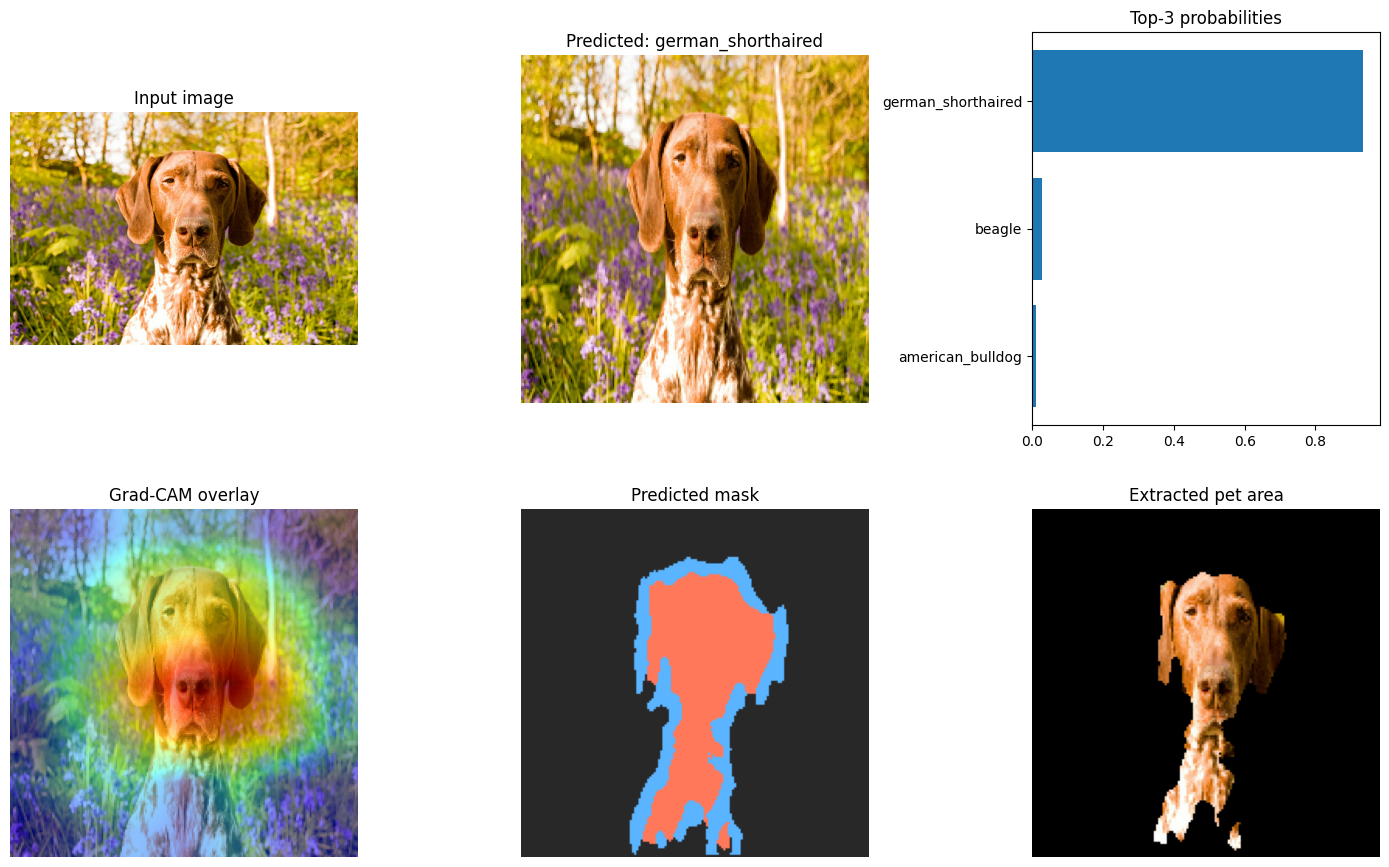

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Input image")
axes[0, 1].imshow(image_for_display)
axes[0, 1].set_title(f"Predicted: {top3[0][0]}")
axes[0, 2].barh([name for name, _ in top3][::-1], [prob for _, prob in top3][::-1])
axes[0, 2].set_title("Top-3 probabilities")
axes[1, 0].imshow(gradcam_overlay)
axes[1, 0].set_title("Grad-CAM overlay")
axes[1, 1].imshow(colorize_mask(pred_mask))
axes[1, 1].set_title("Predicted mask")
axes[1, 2].imshow(extracted)
axes[1, 2].set_title("Extracted pet area")
for ax in axes.ravel():
    if ax is not axes[0, 2]:
        ax.axis("off")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "results/figures/demo_inference.png", dpi=160)
plt.show()